# `wisesight-sentiment` Data Exploration by [@lukkiddd](https://github.com/lukkiddd)

This notebook perform an exploration of the `wisesight-sentiment` dataset which was provided by **Wisesight (Thailand) Co., Ltd**. It contains 24,063 texts with 4 categories (`q`uestion, `neg`ative, `neu`tral, and `pos`itive) for training set and 2,674 texts for test set. For more detail about the data you can read `README.md` at https://github.com/PyThaiNLP/wisesight-sentiment .
    
- Word length distribution
- TF-IDF
    - Words
    - Emojis
    - Punctuations
    - URLs
    - Hashtags

In [1]:
import re

import pandas as pd

from pathlib import Path

from pythainlp.tokenize import word_tokenize
from tqdm import tqdm_notebook

# For visualization
import seaborn as sns

from matplotlib import pyplot as plt

# params
pd.set_option("max_colwidth", 0)
sns.set_context("talk")
sns.set_palette(sns.color_palette("colorblind", 10))

%matplotlib inline

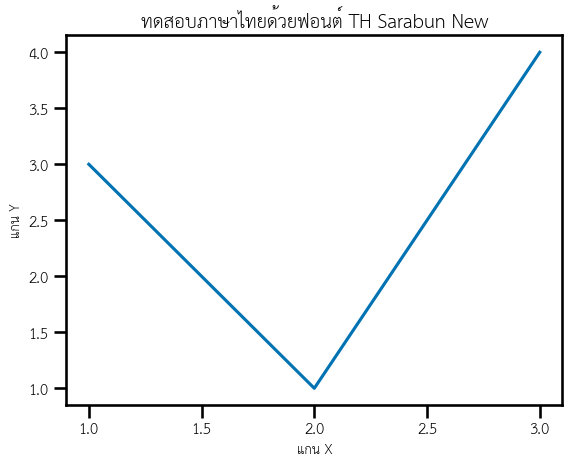

In [2]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

# 🔹 ใส่พาธไปยังไฟล์ฟอนต์ของคุณ
path = r"C:\THSarabunNew.ttf"  # 👈 เปลี่ยนตามจริง
# ถ้าอยู่ในโฟลเดอร์เดียวกับไฟล์ Python ใช้แค่:
# font_path = "THSarabunNew.ttf"

# ✅ ตรวจสอบว่าไฟล์มีอยู่จริง
import os
if not os.path.exists(path):
    raise FileNotFoundError(f"❌ ไม่พบไฟล์ฟอนต์ที่ {path}")

# ✅ ลงทะเบียนฟอนต์ใน matplotlib
font_manager.fontManager.addfont(path)
rcParams["font.family"] = "TH Sarabun New"

# ✅ ทดสอบการพล็อตกราฟภาษาไทย
plt.title("ทดสอบภาษาไทยด้วยฟอนต์ TH Sarabun New", fontsize=20)
plt.plot([1, 2, 3], [3, 1, 4])
plt.xlabel("แกน X", fontsize=14)
plt.ylabel("แกน Y", fontsize=14)
plt.show()


# Reading data

In [3]:
# Set data path
data_folder = Path("kaggle-competition/")

In [4]:
#แปลงชุดข้อมูลการฝึก (Training Dataset) ที่เดิมแยกเก็บเป็นไฟล์ข้อความสำหรับข้อความและป้ายกำกับ ให้กลายเป็น ไฟล์ตาราง .csv ที่พร้อมใช้งานสำหรับการประมวลผลและการฝึกโมเดลต่อไป.
import pandas as pd
from pathlib import Path

data_folder = Path("C:/wisesight-sentiment-master/kaggle-competition")  

texts = []
labels = []


with open(data_folder / "train.txt", encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

with open(data_folder / "train_label.txt", encoding="utf-8") as f:
    for line in f:
        labels.append(line.strip())

df = pd.DataFrame({
    "category": labels,
    "texts": texts
})

df.to_csv("_train.csv", index=False, encoding="utf-8-sig")  
print(df.shape)


(24063, 2)


In [5]:
# Generate _test.csv from test.txt, use "neu" as the only class
texts = []
labels = []

with open(data_folder / "test.txt", encoding="utf-8") as f:
    for line in f:
        texts.append(line.strip())

test_df = pd.DataFrame({
    "category": "neu",
    "texts": texts
})

test_df.to_csv("_test.csv", index=False, encoding="utf-8-sig") 
print(test_df.shape)


(2674, 2)


In [6]:
df.describe()
# count	จำนวนข้อมูลที่ไม่ใช่ค่าว่าง
# unique	จำนวนค่าที่ไม่ซ้ำกัน 
# top	ค่าที่ปรากฏบ่อยที่สุด 
# freq	ความถี่ของค่าที่ปรากฏบ่อยที่สุด 

,category,texts
count,24063,24063
unique,4,24014
top,neu,#ERROR!
freq,13105,31


In [7]:
df.groupby("category").describe()
# neg	Negativeเชิงลบ 
# neu	Neutralเป็นกลาง 
# pos	Positiveเชิงบวก 
# q	Questionคำถาม 

texts         \
          count unique   
category                 
neg       6140   6129    
neu       13105  13087   
pos       4300   4300    
q         518    518     

                                                                                       \
                                                                                  top   
category                                                                                
neg       #ERROR!                                                                       
neu       #ERROR!                                                                       
pos       สนใจ ฟอจูนเนอร์ สีขาวครับ                                                     
q         นิสสัน suv ที่เพิ่งเปิดตัวที่ฟิลิบปินส์เป็นไงบ้างครับ สมรรถภาพ มาไทยเมื่อไร   

               
         freq  
category       
neg       12   
neu       19   
pos       1    
q         1

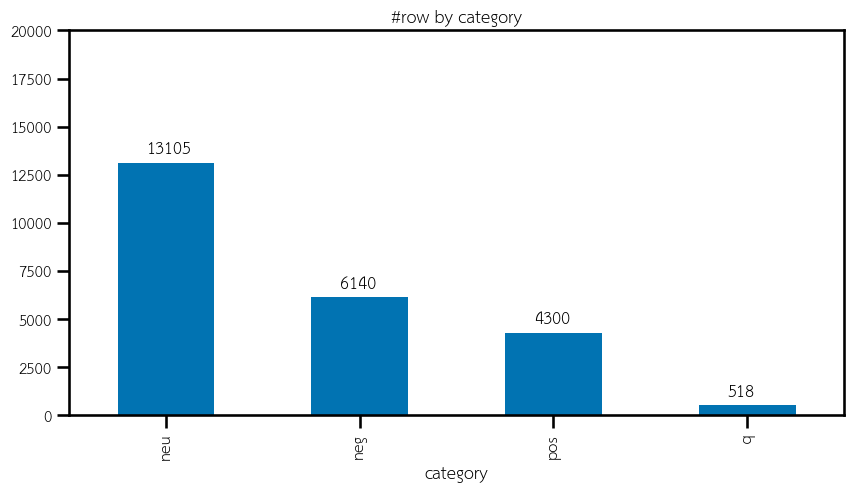

In [8]:
row_count_by_category = df.category.value_counts()

# แก้ไขตรงนี้: เปลี่ยน "bar" เป็น kind="bar"
ax = row_count_by_category.plot(kind="bar", title="#row by category", figsize=(10, 5))

ax.set_ylim(0, 20000)
for i, label in enumerate(row_count_by_category):
    # ปรับตำแหน่ง label ให้เหมาะสมกับบาร์
    ax.annotate(str(label), (i - 0.1, label + 500))

# Text length

In [9]:
#ตรวจนับจำนวนคำในแต่ละข้อความครับ
df["length"] = df["texts"].apply(word_tokenize).apply(len)
df.head()

,category,texts,length
0,neu,ประเทศเราผลิตและส่งออกยาสูบเยอะสุดในโลกจิงป่าวคับ,13
1,neu,คะ,1
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,9
3,neu,😅😅😅,1
4,neu,สวัสดีวันพุธ แนน อะไรนะ,8


<Axes: >

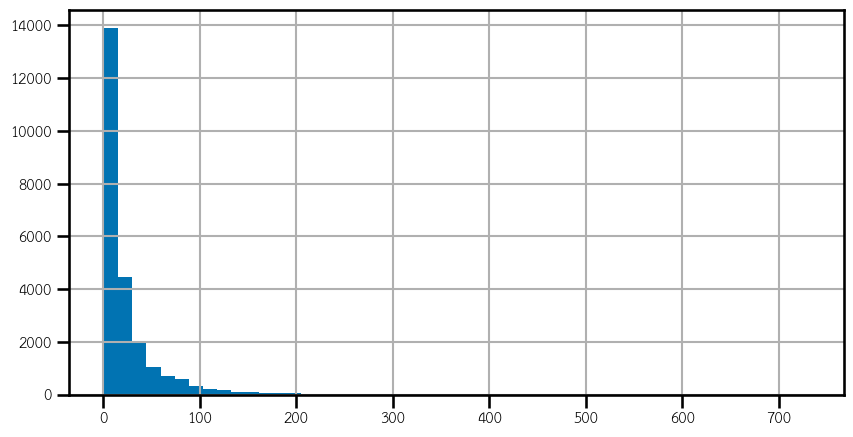

In [10]:
#วิเคราะห์ความยาวข้อความใน DataFrame ด้วยการสร้าง Histogram ครับ
df["length"].hist(bins=50, figsize=(10, 5))

In [11]:
import pandas as pd

# คำนวณสถิติ
desc = df['length'].describe()

# สร้างตารางพร้อมคำอธิบาย
table_data = [
    ["count", int(desc['count']), "จำนวนแถวทั้งหมดที่มีข้อมูลในคอลัมน์นี้"],
    ["mean", round(desc['mean'], 2), "ค่าเฉลี่ยของจำนวนคำต่อข้อความ"],
    ["std", round(desc['std'], 2), "ส่วนเบี่ยงเบนมาตรฐานของความยาวข้อความ"],
    ["min", int(desc['min']), "ข้อความที่สั้นที่สุด"],
    ["25%", int(desc['25%']), "25% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์ล่าง)"],
    ["50%", int(desc['50%']), "Median ของความยาวข้อความ (ค่ากลาง)"],
    ["75%", int(desc['75%']), "75% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์บน)"],
    ["max", int(desc['max']), "ข้อความที่ยาวที่สุด"]
]

# สร้าง DataFrame
summary_table = pd.DataFrame(table_data, columns=["ค่าที่ได้", "ค่า", "ความหมาย"])

# แสดงตาราง
summary_table



,ค่าที่ได้,ค่า,ความหมาย
0,count,24063.00,จำนวนแถวทั้งหมดที่มีข้อมูลในคอลัมน์นี้
1,mean,26.46,ค่าเฉลี่ยของจำนวนคำต่อข้อความ
2,std,43.03,ส่วนเบี่ยงเบนมาตรฐานของความยาวข้อความ
3,min,1.00,ข้อความที่สั้นที่สุด
4,25%,6.00,25% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์ล่าง)
5,50%,12.00,Median ของความยาวข้อความ (ค่ากลาง)
6,75%,29.00,75% ของข้อความมีความยาว ≤ ค่านี้ (ควอร์ไทล์บน)
7,max,731.00,ข้อความที่ยาวที่สุด


In [80]:
df[df["length"] >= 731]

,category,texts,length
5889,neu,"และงานใหญ่ประจำปี บ้ตร sold out ทุกปี - ขายบัตรแล้ว!! พร้อมเพิ่มวง LIPTA - ถึงเวลารวม ชนเผ่า Johnnie Walker present 20Something On The Beach 2018 ""ชน เผ่า เมา เต้น"" ▶ THAITANIUM ▶ UrboyTJ ▶ COCKTAIL ▶ MILD ▶ LIPTA ▶ MUSKETEERS X BETTERWEATHER ▶ บริษัทฮาไม่จำกัด (บอล,ค่อม,ตั๊ก,โรเบิร์ต สายควัน) ▶ Dj Taidy Dj MMM Mc YongHulk ▶ GiraffNoi / RAVEN DOLL PARTY แบบ nonstop ไม่มี dead air DJ สลับ ศิลปินตลอดงาน @The Zign pattaya Sat 03/03/2018 16.00 - until late AGE : 18+ Dress Code : ชนเผ่า ----------------------------------------------- งานแบ่งเป็น 2 zone * Zone Regular : อยู่ด้านหลังไม่ติดเวที มีโต๊ะให้บางส่วน ไม่มีการจอง มาก่อนได้ก่อน ไม่ได้มีพอกับทุกคน เข้า zone vip ไม่ได้ (บัตรทุกราคา free mixer all night) * Regular Ticket - Pre sale : 900 ฿ - Door sale : 1,200 ฿ * Regular Package : 4,900฿ (ไม่มีบุ๊คโต๊ะ ไปก่อนได้ก่อน) - ห้องพัก the zign 1 ห้อง - บัตร regular 2 ใบ - บัตรอาหารเช้า 2 ท่าน — *Zone VIP : อยู่ด้านหน้าติดเวที Zone นี้ทุกโต๊ะจะต้องจองเท่านั้น สำหรับคนที่ ซื้อบัตร vip แยกเป็นใบๆ ต้องมีเพื่อนจองโต๊ะแล้วเท่านั้น ไม่งั้นเข้าไป คุณจะไม่มีโต๊ะ * VIP Ticket (limited) - 1,500 ฿ * VIP Package A : 15,000 ฿ (มีบุ๊คโต๊ะ) - ห้องพัก the zign 1 ห้อง - บัตร vip 4 ใบ - Whisky Johnnie Walker Blenders’ Batch 2 ขวด - Reserve table + VIP toilet - เด็กเสริฟ เครื่องดื่ม - Free mix all night - บัตรอาหารเช้า 2 ท่าน * VIP Package B : 12,000 ฿ (มีบุ๊คโต๊ะ) (สำหรับคนไม่เอาห้อง) - บัตร vip 4 ใบ - Whisky Johnnie Walker Blenders’ Batch - Reserve table + VIP toilet - เด็กเสริฟ เครื่องดื่ม - Free mix all night * VIP Package C : 6,100 ฿ (ไม่มีบุ๊คโต๊ะ) (สำหรับคนที่เพื่อนซื้อโต๊ะแล้ว) - ห้องพัก the zign 1 ห้อง - บัตร vip 2 ใบ - VIP toilet - เด็กเสริฟ เครื่องดื่ม - Free mix all night - บัตรอาหารเช้า 2 ท่าน ----------------------------------------------- ซื้อบัตรคลิก : http://go.eventpop.me/20STHONTHEBEACH2018 ซื้อบัตรกับทางร้าน (เฉพาะโต๊ะ vip zone ครึ่งหลัง) LINE@20sth : https://goo.gl/ujgAK4 Party by ""20STH TEAM"" #20somethingonthebeach2018 #20somethingonthebeach #ชนเผ่าเมาเต้น",731


### Word length distribution

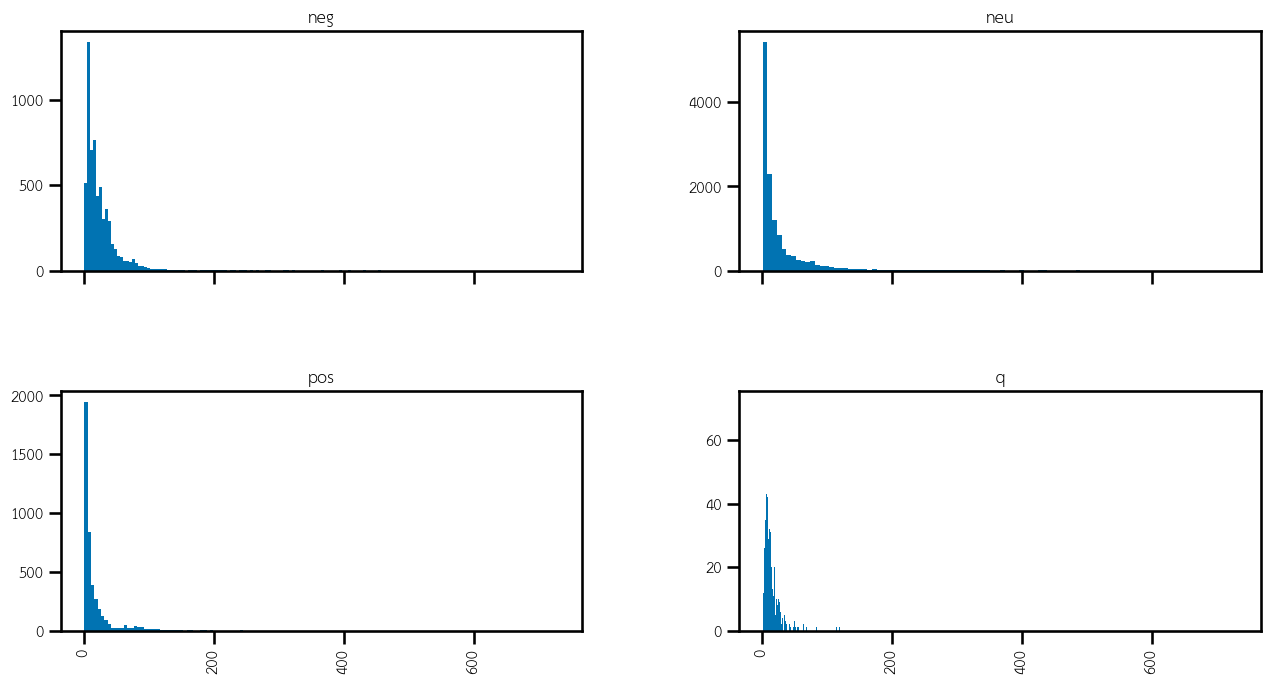

In [81]:
df.hist(column="length", by="category", bins=100, figsize=(15,8), sharex=True)
plt.show()

### Word length distribution (< 100)

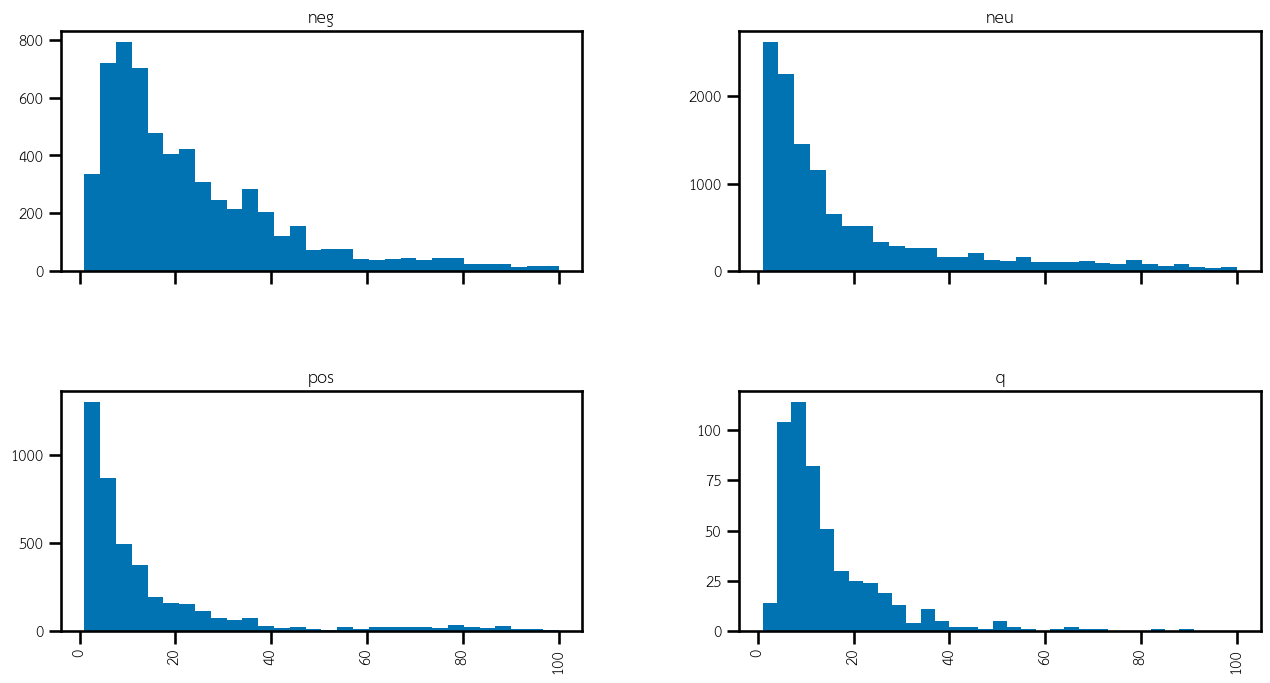

In [82]:
df[df["length"] <= 100].hist(column="length", by="category", bins=30, figsize=(15,8), sharex=True)
plt.show()

# Preprocess

In [83]:
# ฟังก์ชันนี้ทำหน้าที่เป็นตัวช่วยในการ ทำความเข้าใจ (Interpretability) โมเดล TF-IDF โดยการแสดงผลในรูปแบบที่มนุษย์อ่านและตีความได้ง่าย
def top_feats(row, features, top_n=25):
    ''' Get top n tfidf values in row and return them with their corresponding feature names.'''

    topn_ids = np.argsort(row)[::-1][:top_n]
    top_feats = [(features[i], row[i]) for i in topn_ids]
    df = pd.DataFrame(top_feats)
    df.columns = ["feature", "score"]

    return df

In [84]:
#ระบุคำศัพท์ (Features) ที่มีความโดดเด่นและมีนัยสำคัญที่สุดโดยเฉลี่ยในกลุ่มเอกสาร
def top_mean_feats(Xtr, features, grp_ids=None, min_tfidf=0.1, top_n=25):
    ''' Return the top n features that on average are most important amongst documents in rows
        indentified by indices in grp_ids. '''

    if grp_ids:
        D = Xtr[grp_ids].toarray()
    else:
        D = Xtr.toarray()

    D[D < min_tfidf] = 0
    tfidf_means = np.mean(D, axis=0)

    return top_feats(tfidf_means, features, top_n)

In [85]:
#วิเคราะห์และแสดงคำศัพท์ (Features) ที่มีความสำคัญสูงสุดโดยเฉลี่ยสำหรับแต่ละหมวดหมู่ความรู้สึก (Sentiment Class) โดยเฉพาะ
def top_feats_by_class(Xtr, y, features, min_tfidf=0.1, top_n=25):
    ''' Return a list of dfs, where each df holds top_n features and their mean tfidf value
        calculated across documents with the same class label. '''

    dfs = []
    labels = np.unique(y)

    for label in labels:
        ids = np.where(y==label)
        feats_df = top_mean_feats(Xtr, features, ids, min_tfidf=min_tfidf, top_n=top_n)
        feats_df.label = label
        dfs.append(feats_df)

    return dfs

In [86]:
#แสดงผลข้อมูลคำศัพท์ (Features) ที่มีความสำคัญสูงสุดของแต่ละคลาสความรู้สึก
def plot_classfeats_h(dfs, score_name=''):
    ''' Plot the data frames returned by the function plot_tfidf_classfeats(). '''

    fig = plt.figure(figsize=(12, 9), facecolor="w")
    x = np.arange(len(dfs[0]))

    for i, df in enumerate(dfs):
        ax = fig.add_subplot(1, len(dfs), i+1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_frame_on(False)
        ax.get_xaxis().tick_bottom()
        ax.get_yaxis().tick_left()
        ax.set_xlabel(f"Mean {score_name} Score", labelpad=16, fontsize=14)
        ax.set_title("label = " + str(df.label), fontsize=16)
        ax.ticklabel_format(axis='x', style='sci', scilimits=(-2,2))
        ax.barh(x, df.score, align='center', color='#3F5D7D')
        ax.set_yticks(x)
        ax.set_ylim([-1, x[-1]+1])
        ax.invert_yaxis()
        yticks = ax.set_yticklabels(df.feature)
        plt.subplots_adjust(bottom=0.09, right=0.97, left=0.15, top=0.95, wspace=0.52)

    plt.show()

In [87]:
#สำหรับการวิเคราะห์และแสดงผลคำศัพท์
def show_classfeats(df, vectorizer, analyzer, score_name='', text_col='texts', class_col='category', is_emoji=False):
    vec = vectorizer(analyzer=analyzer)
    mat = vec.fit_transform(df[text_col])
    dfs = top_feats_by_class(mat, df[class_col], vec.get_feature_names())

    if is_emoji:
        for dataframe in dfs:
            dataframe.columns = [dataframe.label, 'tfidf_' + dataframe.label]
        return pd.concat(dfs, axis=1)
    else:
        plot_classfeats_h(dfs, score_name=score_name)

In [88]:
#ฟังก์ชันการประมวลผลข้อความล่วงหน้าที่ใช้ในการแยกหรือกรององค์ประกอบเฉพาะจากข้อความภาษาไทย
import string
import emoji
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

def process_text(text):
    nopunc = [char for char in text if char not in string.punctuation]
    nopunc = "".join(nopunc)
    
    return [word for word in word_tokenize(nopunc) if word and not re.search(pattern=r"\s+", string=word)]

def extract_url(text):
    URL_PATTERN = r"(https?:\/\/)?\.([\da-z-]+)\.([a-z\.]{2,6})([\/\w\.-]*)*\/?\S"
    return [url[1] for url in re.findall(pattern=URL_PATTERN, string=text.lower())]

def extract_emojis(str):
    return [c for c in str if c in emoji.UNICODE_EMOJI]

def extract_punc(text):
    return [char for char in text if char in string.punctuation]

def extract_hashtags(text):
    HASHTAG_PATTERN = r"#[a-zA-Z0-9ก-๙]+"
    return re.findall(pattern=HASHTAG_PATTERN, string=text)

## TF-IDF

### Words

In [92]:
show_classfeats(
    df=df[:1000],
    vectorizer=TfidfVectorizer,
    analyzer=process_text,
    score_name="tf-idf",
)

KeyError: 'text'

### Emojis

In [23]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_emojis)

AttributeError: module 'emoji' has no attribute 'UNICODE_EMOJI'

### Punctuations

In [24]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_punc)

AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

### URLs

In [25]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_url)

AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

### Hashtags

In [26]:
show_classfeats(df=df, vectorizer=TfidfVectorizer, score_name="tf-idf", analyzer=extract_hashtags)

AttributeError: 'TfidfVectorizer' object has no attribute 'get_feature_names'

# Neutral, Positive, Negative

In [27]:
#เลือกตัวอย่างข้อมูลความเป็นกลาง
neu_df = df[df.category == "neu"].sample(5000)
neu_df.head()

,category,texts,length
19121,neu,"ข้อเสนอพิเศษ All New Suzuki SWIFT กับ โปรแกรม My Way ผ่อนเริ่มต้นเพียง 3,999 บาท ต่อเดือน และแคมเปญพิเศษ Loyalty Program สำหรับลูกค้า SWIFT เพียงนำ SWIFT คันเดิมมาเปลี่ยนเป็น SWIFT ใหม่ รับทันทีส่วนลดอุปกรณ์ตกแต่ง 20,000 บาทค่า ติดตามรายละเอียดเพิ่มเติมได้ที่ www.allnewsuzukiswift.com",75
13842,neu,กูไม่กินลีโอ.,5
17138,neu,มีลามไปยันคออ่ะ,6
10550,neu,ใช่เลยค่าาา กลับไปจัดนะ😍😍,10
20792,neu,ว่าไงค่าาา,4


In [28]:
#แยกเฉพาะข้อมูลที่มีความรู้สึกเป็นเชิงบวก (Positive Sentiment) ออกจาก DataFrame หลัก
pos_df = df[df.category == "pos"]
pos_df.head()

,category,texts,length
10,pos,สนใจ ฟอจูนเนอร์ สีขาวครับ,9
16,pos,ไปดิ..รอไร,5
19,pos,อยากกินบาบีก้อนหรอ555555,6
22,pos,ต้องไปลองกันนะ,5
25,pos,ขอให้ SHEENe มีกิจการรุ่งเรือง ขายดีๆ ยอดไลท์เพจเยอะๆ มีสินค้าคุณภาพออกมาให้ผู้บริโภคมากๆ ให้ SHEENeดูแลคนไทยไปตลอดไปครับ,34


In [29]:
neg_df = df[df.category == "neg"]
neg_df.head()

,category,texts,length
2,neg,อิเหี้ยออมทำกูอยากกินเอ็มเค,9
6,neg,เน็ตควายมากกูพูดจริงเสียดายตังค์ที่ติดตั้งเน็ตโครตห่วยยิ่งดึกๆเน็ตยิ่งห่วยตอนมาติดตั้งใหม่ๆก็ดีนานๆไปเเย่ขึ้นเรื่อยๆกากกว่าเน็ตค่ายอื่นอ่ะบอกจริงไม่สนหรอกว่าจะเป็นเด็กเเล้วเม้นด่าเเบบนี้ เเต่นี้หาตังค์จ่ายค่าเน็ตมาตลอดเหนื่อยน่ะเล่นเกมส์ไปเดี่ยวก็หายกากเกินติดตั้งโปรพิเศษ100Mเเต่พอวัดดูปล่อยไม่ถึงเท่าที่ตกลงกันไว้พอโทรไปเเจ้งก็ปล่อยมาเต็มไม่กี่วันก็เหมื่อนเดิมใบเเจ้งก็มาย้อนหลัง3เดือนทุกครั้งห่วยไปน่ะบางทีโปร100M/700 กว่าบาทเเต่คุณภาพเเย่เสียดายตังค์,127
8,neg,เหล้าเบลล์รสชาติเหี้ยสุด จะไม่แดกอีกละ,11
11,neg,ลิปมันของเเบร์น Mistine ราคากลาง ๆ ไม่แพงมาก ราคาสามารถเอื้อมถึงได้ #LASHESactivity,23
12,neg,ทำไมมันไม่มีโปรให้เร๊าาาาาา,7


In [30]:
sentiment_df = pd.concat([neg_df, pos_df, neu_df])
sentiment_df = sentiment_df.reset_index(drop=True)
sentiment_df.groupby("category").texts.describe()

,count,unique,top,freq
category,,,,
neg,6140,6129,#ERROR!,12
neu,5000,4997,#ERROR!,4
pos,4300,4300,สนใจ ฟอจูนเนอร์ สีขาวครับ,1


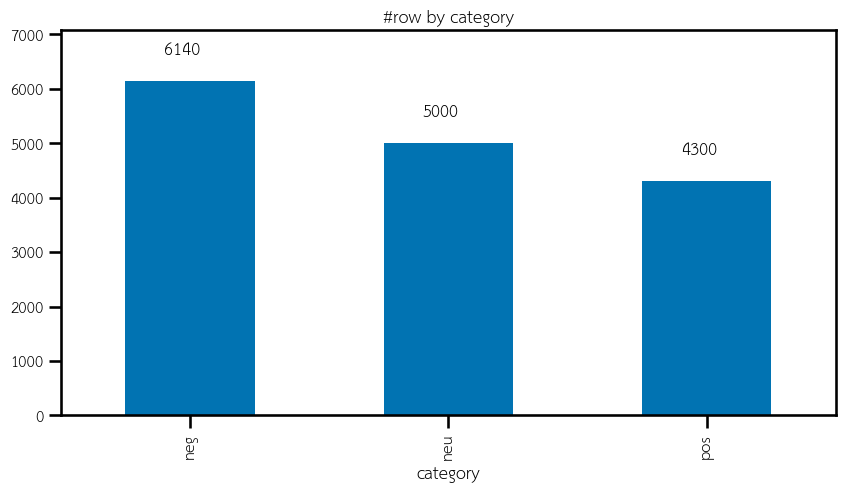

In [31]:
#นับจำนวนข้อมูลในแต่ละประเภท
row_count_by_category = sentiment_df.category.value_counts()

ax = row_count_by_category.plot(
    kind="bar",                      # ✅ ใช้ keyword argument
    title="#row by category",
    figsize=(10, 5)
)

ax.set_ylim(0, row_count_by_category.max() + row_count_by_category.std())

# 🔹 แสดงค่าบนแท่ง
for i, label in enumerate(row_count_by_category):
    ax.annotate(str(label), (i - 0.1, label + 500))

plt.show()


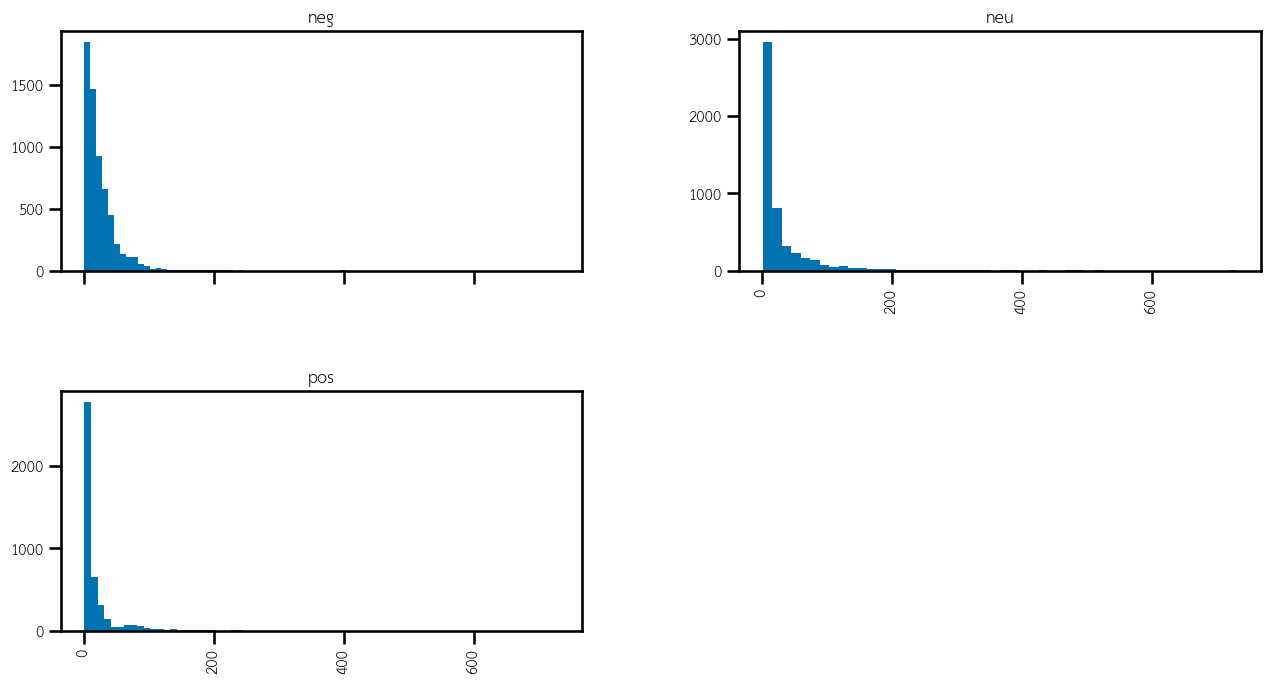

In [32]:
sentiment_df.hist(column="length", by="category", bins=50, figsize=(15, 8), sharex=True)
plt.show()

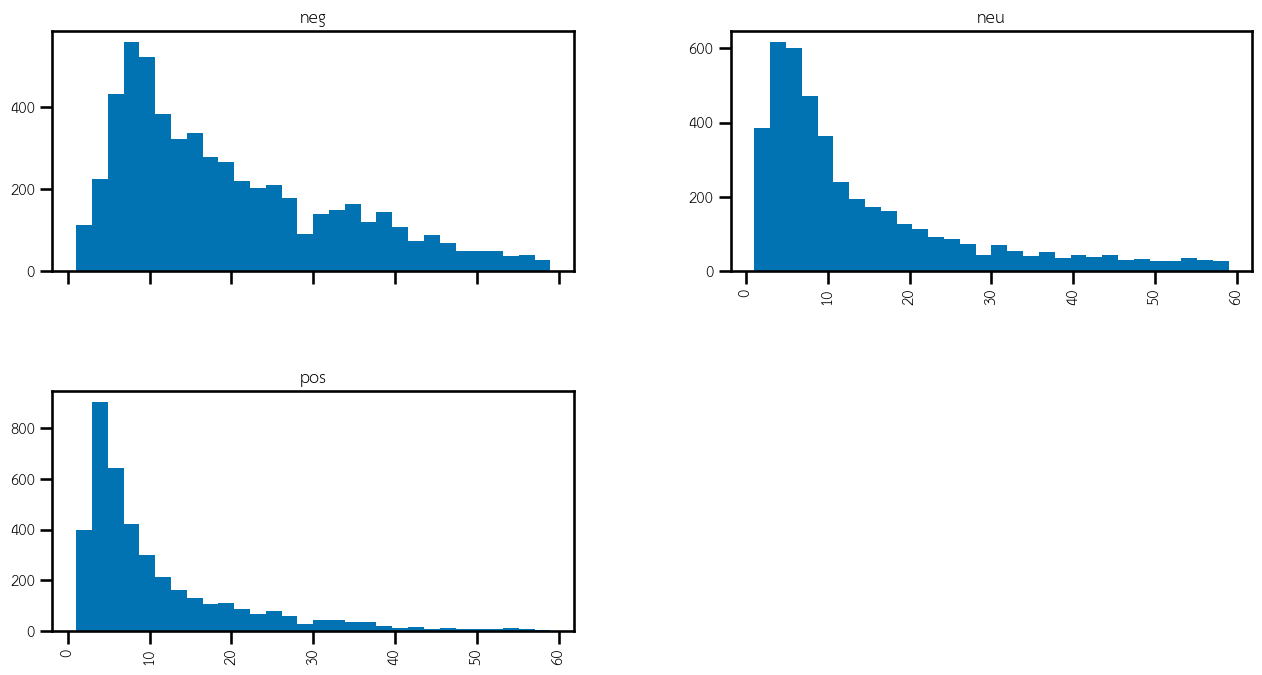

In [33]:
sentiment_df[sentiment_df.length < 60].hist(column="length", by="category", bins=30, figsize=(15, 8), sharex=True)
plt.show()

# Classification

In [34]:
class_names = np.unique(sentiment_df.category).tolist()

## Multinomial Naive Bayes (default parameters)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(sentiment_df["texts"], sentiment_df["category"], test_size=0.20, random_state=42)

In [36]:
#สร้างโมเดลการจำแนกประเภทข้อความ
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.naive_bayes import MultinomialNB

#การสร้าง Pipeline
text_clf = Pipeline([
    #แปลงข้อมูลข้อความ (Text) ให้เป็นเวกเตอร์ของจำนวนคำ (Term Count) โดยใช้ฟังก์ชัน process_text ในการ Tokenize และพิจารณา N-gram (คู่คำหรือคำเดี่ยว) ในช่วง (1, 2)
    ("vect", CountVectorizer(tokenizer=process_text, ngram_range=(1,2))), 
    #แปลงเวกเตอร์จำนวนคำจากขั้นตอนที่ 1 ให้เป็นเวกเตอร์ TF-IDF (Term Frequency-Inverse Document Frequency) 
    ("tfidf", TfidfTransformer()),
    #ใช้โมเดล Multinomial Naive Bayes เพื่อเรียนรู้และจำแนกประเภท (Sentiment) โดยมี alpha=0.001 เป็นพารามิเตอร์ปรับเรียบ (Smoothing)
    ("clf", MultinomialNB(alpha=0.001)),
])

#train model
text_clf.fit(X_train, y_train)
text_clf.score(X_test, y_test)

C:\Program Files\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.6492875647668394

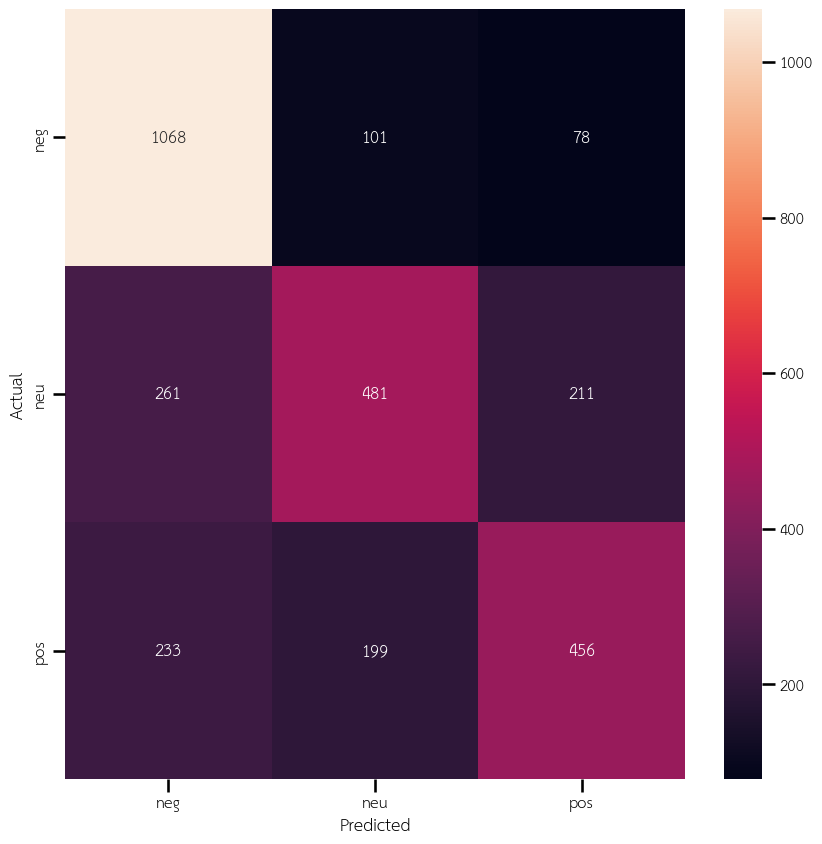

In [37]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, text_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

#### LIME Explainer

In [38]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=class_names)

In [39]:
idx = sentiment_df.sample(1).index[0]

exp = explainer.explain_instance(
    sentiment_df.texts[idx],
    text_clf.predict_proba,
    num_features=5,
    top_labels=1
)

from IPython.display import display, HTML


html = exp.as_html()
styled_html = f"""
<div style="background-color: white; color: black; padding: 20px; border-radius: 10px;">
{html}
</div>
"""

display(HTML(styled_html))


In [40]:
sentiment_df.iloc[idx]

category    neg                                                        
texts       ลองเส่ะ แต่ข้าว่ามันหวานไป แต่ยอมรับว่ามันกินลื่นดีดื่มง่าย
length      19                                                         
Name: 4667, dtype: object

## Linear SVC (default parameters)

In [41]:
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

svc_clf = Pipeline([
    ("vect", CountVectorizer(tokenizer=process_text, ngram_range=(1,2))),
    ("tfidf", TfidfTransformer()),
    ("clf", LinearSVC()),
])

svc_clf.fit(X_train, y_train)
svc_clf.score(X_test, y_test)

C:\Program Files\Python313\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


0.6936528497409327

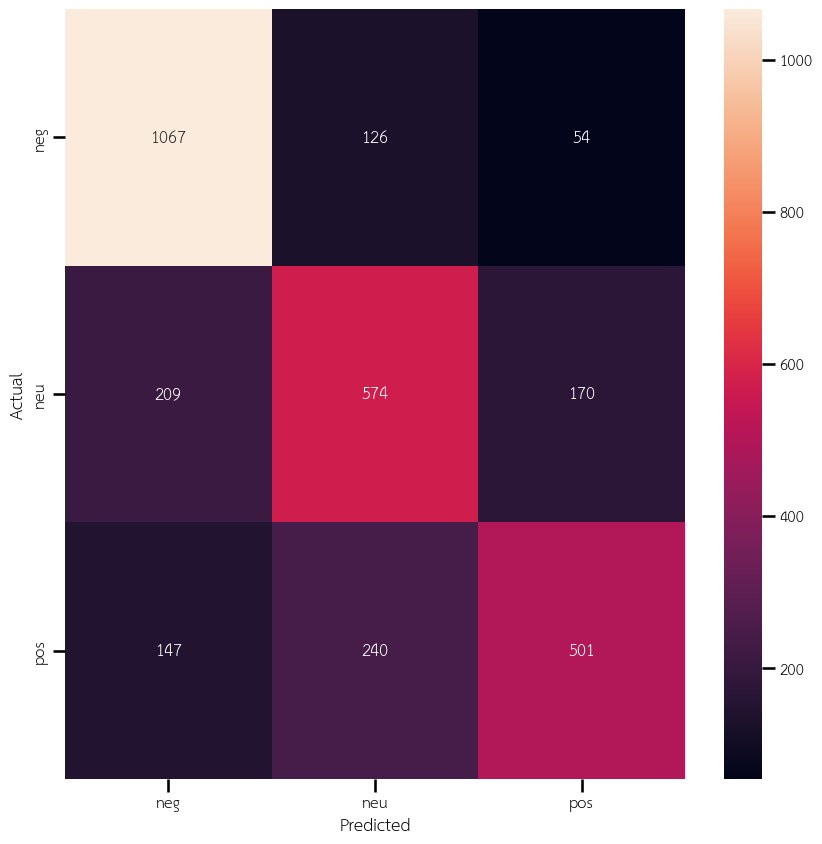

In [42]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(y_test, svc_clf.predict(X_test))
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt="d",
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [ ]:
##CNN-BiLSTM

In [53]:
import numpy as np  # นำเข้าไลบรารีสำหรับการจัดการตัวเลขและอาเรย์
from sklearn.preprocessing import LabelEncoder  # สำหรับแปลง label เป็นตัวเลข
from tensorflow.keras.preprocessing.text import Tokenizer  # สำหรับแปลงข้อความเป็น sequence ของตัวเลข
from tensorflow.keras.preprocessing.sequence import pad_sequences  # สำหรับปรับความยาว sequence ให้เท่ากัน
from tensorflow.keras.utils import to_categorical  # สำหรับแปลง label เป็น one-hot encoding
from tensorflow.keras.models import Sequential  # สำหรับสร้างโมเดล Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout  # นำเข้า layer ต่าง ๆ

# =========================
# 🔹 แปลง labels เป็นตัวเลข
# =========================
le = LabelEncoder()  # สร้างตัวแปลง LabelEncoder
y = le.fit_transform(sentiment_df['category'])  # แปลง category เป็นตัวเลข เช่น "positive"->2, "neutral"->1
y_cat = to_categorical(y)  # แปลงเป็น one-hot encoding เช่น 2->[0,0,1]

# =========================
# 🔹 แบ่งข้อมูลเป็น train/test
# =========================
from sklearn.model_selection import train_test_split  # นำเข้า train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    sentiment_df['texts'], y_cat, test_size=0.2, random_state=42
)
# test_size=0.2 หมายถึง 20% ของข้อมูลจะเป็น test set
# random_state=42 กำหนด seed เพื่อให้ผลลัพธ์ซ้ำได้

# =========================
# 🔹 Tokenize ข้อความ
# =========================
max_words = 10000  # จำนวนคำสูงสุดที่ tokenizer จะเก็บ
max_len = 194      # ความยาว sequence สูงสุด (เกินนี้จะถูกตัด) 
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")  # สร้าง tokenizer และกำหนด token สำหรับคำที่ไม่รู้จัก
tokenizer.fit_on_texts(X_train)  # สร้าง vocabulary จาก train data

X_train_seq = tokenizer.texts_to_sequences(X_train)  # แปลงข้อความ train เป็น sequence ของตัวเลข
X_test_seq = tokenizer.texts_to_sequences(X_test)    # แปลงข้อความ test เป็น sequence ของตัวเลข

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')  # เติม 0 ด้านท้ายเพื่อให้ความยาวเท่ากัน
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')    # เติม 0 ด้านท้ายเช่นเดียวกัน

# =========================
# 🔹 สร้างโมเดล CNN-BiLSTM
# =========================
model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    # 🔹 Embedding layer แปลงเลข word index เป็น vector ขนาด 128

    Conv1D(32, kernel_size=2, activation='relu', padding='same'),
    # 🔹 Conv1D layer kernel size 2 จำนวน filter=32, activation ReLU, padding=same (ไม่ลดขนาด sequence)
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling1D ลดขนาด sequence ลงครึ่งหนึ่ง

    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    # 🔹 Conv1D layer kernel size 3 จำนวน filter=32, activation ReLU, padding=same
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling1D อีกครั้ง ลดขนาด sequence

    Bidirectional(LSTM(64, return_sequences=False)),
    # 🔹 BiLSTM layer 64 units (รวมสองทิศทาง), return_sequences=False เพราะต้องการ output vector เดียว

    Dropout(0.5),
    # 🔹 Dropout 50% เพื่อลด overfitting

    Dense(y_cat.shape[1], activation='softmax')
    # 🔹 Dense layer output size = จำนวน class, activation softmax สำหรับ multi-class classification
])

# =========================
# 🔹 Compile โมเดล
# =========================
from tensorflow.keras.optimizers import Adam  # นำเข้า optimizer Adam
optimizer = Adam(learning_rate=0.001)  # กำหนด learning rate 0.001
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
# loss=categorical_crossentropy เพราะเป็น multi-class classification
# metrics=['accuracy'] เพื่อดูค่าความแม่นยำ

model.summary()  # แสดงสรุปโครงสร้างโมเดล

# =========================
# 🔹 Train โมเดล
# =========================
history = model.fit(
    X_train_pad, y_train,  # ข้อมูล train
    validation_data=(X_test_pad, y_test),  # ข้อมูล validation
    epochs=30,              # จำนวนรอบการ train
    batch_size=64,          # จำนวนตัวอย่างต่อ batch
    verbose=1               # แสดง progress bar
)


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_11 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_12 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_12 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_6 (Bidirectional)      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4192 - loss: 1.0710 - val_accuracy: 0.4942 - val_loss: 1.0067
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5171 - loss: 0.9875 - val_accuracy: 0.5210 - val_loss: 0.9784
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6057 - loss: 0.8422 - val_accuracy: 0.5233 - val_loss: 1.0017
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6704 - loss: 0.6941 - val_accuracy: 0.5262 - val_loss: 1.0658
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7026 - loss: 0.6173 - val_accuracy: 0.5246 - val_loss: 1.1102
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7116 - loss: 0.5974 - val_accuracy: 0.5172 - val_loss: 1.1967
Epoch 7/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7119 - loss: 0.5755 - val_accuracy: 0.5217 - val_loss: 1.2698
Epoch 8/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7262 - loss: 0.5543 - val_accu

In [62]:
from sklearn.metrics import classification_report

# ทำนายผลบนชุดทดสอบ
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# แสดง classification report แบบข้อความ
report_text = classification_report(y_true, y_pred, target_names=le.classes_)
print(report_text)



97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
              precision    recall  f1-score   support

         neg       0.58      0.64      0.61      1247
         neu       0.53      0.31      0.39       953
         pos       0.41      0.53      0.47       888

    accuracy                           0.51      3088
   macro avg       0.51      0.50      0.49      3088
weighted avg       0.52      0.51      0.50      3088



97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


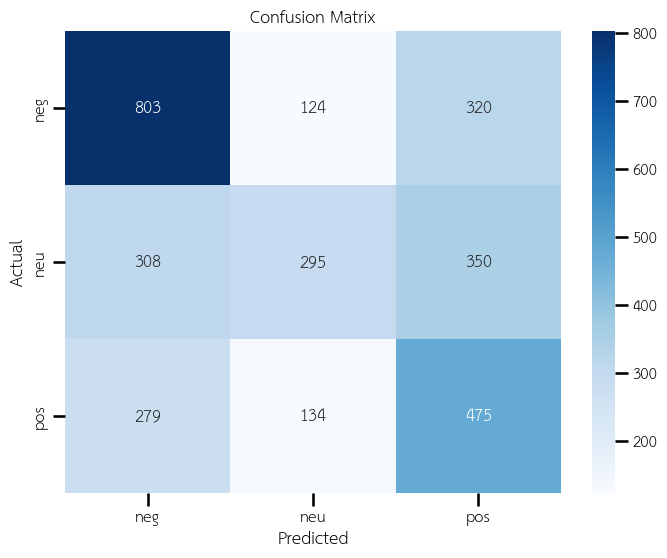

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

#ทำนายผล
y_pred_prob = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

#สร้าง confusion matrix
conf_mat = confusion_matrix(y_true, y_pred)

#วาด heatmap
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt="d", 
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
#BiLSTM-CNN

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_19 (Embedding)             │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_19 (Bidirectional)     │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_34 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_29 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_35 (Conv1D)                   │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_30 (MaxPooling1D)      │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_10              │ ?                           │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - accuracy: 0.4143 - loss: 1.0718 - val_accuracy: 0.4926 - val_loss: 1.0106
Epoch 2/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.5111 - loss: 0.9777 - val_accuracy: 0.5194 - val_loss: 0.9815
Epoch 3/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - accuracy: 0.5689 - loss: 0.8734 - val_accuracy: 0.5207 - val_loss: 1.0306
Epoch 4/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.6154 - loss: 0.7934 - val_accuracy: 0.5246 - val_loss: 1.0416
Epoch 5/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.6644 - loss: 0.7050 - val_accuracy: 0.5217 - val_loss: 1.1170
Epoch 6/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 78ms/step - accuracy: 0.6812 - loss: 0.6694 - val_accuracy: 0.5120 - val_loss: 1.1843
Epoch 7/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 79ms/step - accuracy: 0.6857 - loss: 0.6431 - val_accuracy: 0.5214 - val_loss: 1.2892
Epoch 8/30
193/193 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.6921 - loss: 0.6238 - 

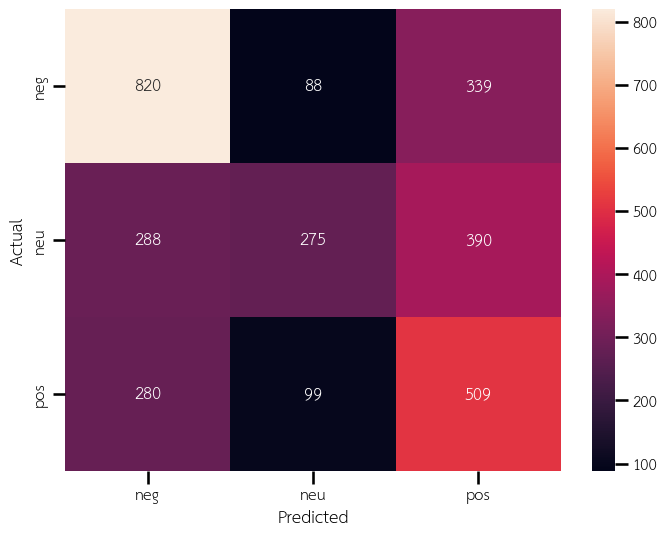

In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D
# นำเข้า Layer และ Model สำหรับสร้าง BiLSTM-CNN

# =========================
# 🔹 พารามิเตอร์
# =========================
max_words = 10000  # จำนวนคำสูงสุดใน vocabulary
max_len = 194      # ความยาว sequence สูงสุด (เกินนี้จะถูกตัด)

# =========================
# 🔹 สร้างโมเดล BiLSTM-CNN
# =========================
bilstm_cnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    # 🔹 Embedding layer แปลง word index เป็น vector ขนาด 128

    Bidirectional(LSTM(64, return_sequences=True)),
    # 🔹 BiLSTM 64 units, return_sequences=True เพื่อให้ output เป็น sequence (ต่อให้ Conv1D ใช้)

    Conv1D(32, kernel_size=2, activation='relu', padding='same'),
    # 🔹 Conv1D kernel size 2, filter 32, activation ReLU
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling1D ลดความยาว sequence ลงครึ่งหนึ่ง

    Conv1D(32, kernel_size=3, activation='relu', padding='same'),
    # 🔹 Conv1D kernel size 3, filter 32, activation ReLU
    MaxPooling1D(pool_size=2),
    # 🔹 MaxPooling1D อีกครั้ง ลดความยาว sequence ลงครึ่งหนึ่ง

    GlobalMaxPooling1D(),
    # 🔹 GlobalMaxPooling1D แปลง sequence เป็น vector เดียวด้วยการเอาค่าสูงสุดในแต่ละ filter

    Dropout(0.5),
    # 🔹 Dropout 50% เพื่อลด overfitting

    Dense(y_cat.shape[1], activation='softmax')
    # 🔹 Dense layer output = จำนวน class, activation softmax สำหรับ multi-class classification
])

# =========================
# 🔹 Compile โมเดล
# =========================
bilstm_cnn_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# loss=categorical_crossentropy สำหรับ multi-class classification
# optimizer='adam' ใช้ Adam optimizer
# metrics=['accuracy'] เพื่อดูค่า accuracy

bilstm_cnn_model.summary()  # แสดงสรุปโครงสร้างโมเดล

# =========================
# 🔹 Train โมเดล
# =========================
history_bilstm_cnn = bilstm_cnn_model.fit(
    X_train_pad, y_train,  # ข้อมูล train
    validation_data=(X_test_pad, y_test),  # ข้อมูล validation
    epochs=30,              # จำนวนรอบการ train
    batch_size=64           # จำนวนตัวอย่างต่อ batch
)

# =========================
# 🔹 ประเมินผล F1-score และ Confusion Matrix
# =========================
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 ทำนายผล test set
y_pred_prob = bilstm_cnn_model.predict(X_test_pad)
y_pred = np.argmax(y_pred_prob, axis=1)  # แปลง probability เป็น class index
y_true = np.argmax(y_test, axis=1)        # แปลง one-hot test label เป็น class index

# 🔹 Classification Report (Precision, Recall, F1-score)
print(classification_report(y_true, y_pred, target_names=le.classes_))

# 🔹 Confusion Matrix
conf_mat = confusion_matrix(y_true, y_pred)  # สร้าง confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')  # แกน x = predicted label
plt.ylabel('Actual')     # แกน y = actual label
plt.show()  # แสดง heatmap ของ confusion matrix


C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)   │ (None, 194)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_24 (Embedding)      │ (None, 194, 128)          │       1,280,000 │ input_layer_20[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_44 (Conv1D)            │ (None, 194, 32)           │           8,224 │ embedding_24[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_35              │ (None, 97, 32)            │               0 │ conv1d_44[0][0]            │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_45 (Conv1D)            │ (None, 97, 32)            │           3,104 │ max_pooling1d_35[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional_24              │ (None, 194, 128)          │          98,816 │ embedding_24[0][0]         │
│ (Bidirectional)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling1d_36              │ (None, 48, 32)            │               0 │ conv1d_45[0][0]            │
│ (MaxPooling1D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_19       │ (None, 128)               │               0 │ bidirectional_24[0][0]     │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_20       │ (None, 32)                │               0 │ max_pooling1d_36[0][0]     │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_5 (Concatenate)   │ (None, 160)               │               0 │ global_max_pooling1d_19[0… │
│                               │                           │                 │ global_max_pooling1d_20[0… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_24 (Dropout)          │ (None, 160)               │               0 │ concatenate_5[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_24 (Dense)              │ (None, 3)                 │             483 │ dropout_24[0][0]           │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,390,627 (5.30 MB)

 Trainable params: 1,390,627 (5.30 MB)

 Non-trainable params: 0 (0.00 B)

193/193 ━━━━━━━━━━━━━━━━━━━━ 17s 81ms/step - accuracy: 0.4128 - loss: 1.0871 - val_accuracy: 0.4955 - val_loss: 1.0054
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
=== Parallel Hybrid Classification Report ===
              precision    recall  f1-score   support

         neg       0.52      0.76      0.62      1247
         neu       0.67      0.23      0.34       953
         pos       0.39      0.42      0.40       888

    accuracy                           0.50      3088
   macro avg       0.53      0.47      0.45      3088
weighted avg       0.53      0.50      0.47      3088

F1-score (macro): 0.4531
F1-score (micro): 0.4955
F1-score (weighted): 0.4697


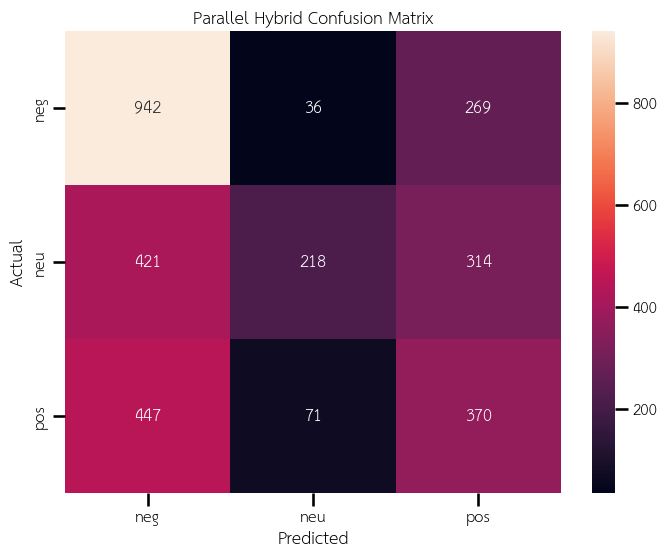

In [78]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D, Concatenate
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# =========================
# Parallel Hybrid Model
# =========================

# 🔹 พารามิเตอร์
max_words = 10000       # จำนวนคำสูงสุดใน vocabulary
max_len = 194           # ความยาว sequence สูงสุด
embedding_dim = 128     # ขนาด vector embedding
learning_rate = 0.001   # learning rate
batch_size = 64         # ขนาด batch
epochs_parallel = 1     # จำนวน epoch (ทดสอบ 1 รอบก่อน)

# =========================
# 🔹 Input & Embedding
# =========================
input_layer = Input(shape=(max_len,))
# สร้าง input layer shape=(max_len,)
embedding_layer = Embedding(input_dim=max_words, output_dim=embedding_dim, input_length=max_len)(input_layer)
# แปลงเลขคำเป็น embedding vector ขนาด embedding_dim

# =========================
# 🔹 BiLSTM branch
# =========================
bilstm_branch = Bidirectional(LSTM(64, return_sequences=True))(embedding_layer)
# BiLSTM 64 units, return_sequences=True เพื่อ output เป็น sequence
bilstm_branch = GlobalMaxPooling1D()(bilstm_branch)
# GlobalMaxPooling แปลง sequence เป็น vector เดียวด้วยการเอาค่าสูงสุดในแต่ละ feature

# =========================
# 🔹 CNN branch
# =========================
conv_branch = Conv1D(32, kernel_size=2, activation='relu', padding='same')(embedding_layer)
# Conv1D kernel size=2, filter=32, activation=ReLU
conv_branch = MaxPooling1D(pool_size=2)(conv_branch)
# MaxPooling ลดความยาว sequence ลงครึ่งหนึ่ง
conv_branch = Conv1D(32, kernel_size=3, activation='relu', padding='same')(conv_branch)
# Conv1D kernel size=3, filter=32
conv_branch = MaxPooling1D(pool_size=2)(conv_branch)
# MaxPooling อีกครั้ง
conv_branch = GlobalMaxPooling1D()(conv_branch)
# GlobalMaxPooling แปลง sequence เป็น vector เดียว

# =========================
# 🔹 รวมสอง branch
# =========================
merged = Concatenate()([bilstm_branch, conv_branch])
# รวม vector จาก BiLSTM branch และ CNN branch
dropout = Dropout(0.5)(merged)
# Dropout 50% เพื่อลด overfitting
output = Dense(y_cat.shape[1], activation='softmax')(dropout)
# Dense output layer จำนวน node = จำนวน class, activation softmax

# =========================
# 🔹 สร้างและ compile โมเดล
# =========================
parallel_model = Model(inputs=input_layer, outputs=output)
parallel_model.compile(
    loss='categorical_crossentropy',    # loss สำหรับ multi-class
    optimizer=Adam(learning_rate=learning_rate),
    metrics=['accuracy']
)

parallel_model.summary()  # แสดง summary ของโมเดล

# =========================
# 🔹 Train โมเดล
# =========================
history_parallel = parallel_model.fit(
    X_train_pad, y_train,                    # ข้อมูล train
    validation_data=(X_test_pad, y_test),    # ข้อมูล validation
    epochs=epochs_parallel,                  # จำนวน epoch
    batch_size=batch_size                     # batch size
)

# =========================
# 🔹 ประเมิน Parallel Hybrid
# =========================
y_pred_prob_parallel = parallel_model.predict(X_test_pad)
# ทำนาย probability ของแต่ละ class
y_pred_parallel = np.argmax(y_pred_prob_parallel, axis=1)
# แปลง probability เป็น class index
y_true = np.argmax(y_test, axis=1)
# แปลง one-hot label เป็น class index

# Classification report
print("=== Parallel Hybrid Classification Report ===")
print(classification_report(y_true, y_pred_parallel, target_names=le.classes_))

# F1-score แบบ macro / micro / weighted
f1_macro = f1_score(y_true, y_pred_parallel, average='macro')
f1_micro = f1_score(y_true, y_pred_parallel, average='micro')
f1_weighted = f1_score(y_true, y_pred_parallel, average='weighted')
print(f"F1-score (macro): {f1_macro:.4f}")
print(f"F1-score (micro): {f1_micro:.4f}")
print(f"F1-score (weighted): {f1_weighted:.4f}")

# Confusion Matrix
conf_mat_parallel = confusion_matrix(y_true, y_pred_parallel)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat_parallel, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Parallel Hybrid Confusion Matrix")
plt.show()
